<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_2_Logistic_Regression_and_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 2 - Logistic Regression and KNN
###STATS 302 Principle of Machine Learning
###Duke Kunshan University

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import files
# import io

## 4.6.1 The Stock Market Data

In [17]:
# !!! Do not use Safari !!!

data = pd.read_csv(r'D:\UG Files\Year 4\S3\STATS 302\Codes\STATS-302-Intro-to-ML\Regression\Week_2_Data\Smarket-1.csv',index_col=0)

# uploaded = files.upload()
# data = pd.read_csv(io.BytesIO(uploaded['Smarket.csv']))
# data = data.drop(data.columns[0], axis=1)
# print(data.shape)
# data.head()

In [32]:
data.tail()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
1246,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,1
1247,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,0
1248,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,1
1249,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,0
1250,2005,-0.298,0.130,-0.955,0.043,0.422,1.38254,-0.489,0


In [4]:
data.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [5]:
data.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000


In [6]:
#produces a correlation matrix for all the numeric columns
corr = data.iloc[:, :-1].corr() 
# data.iloc[rows, columns], all rows and columns except the last column
corr

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


<Axes: >

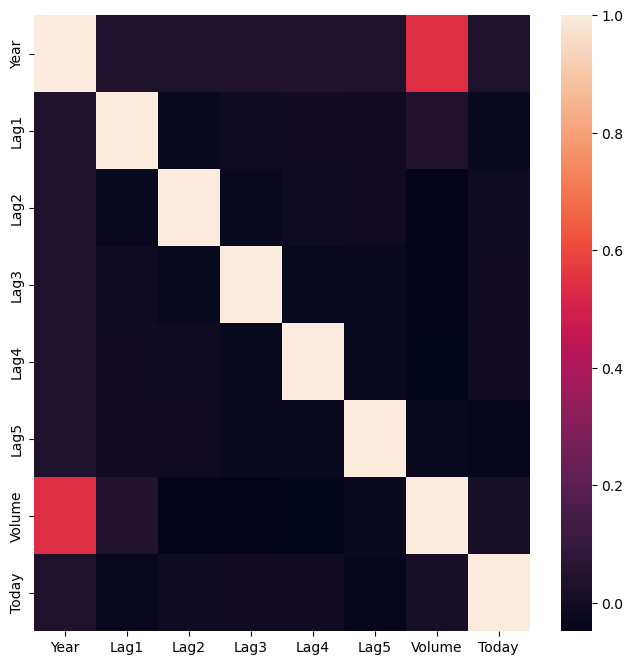

In [8]:
# the best way to visualize corerelations matrices is heatmap
plt.figure(figsize = (8,8))
sns.heatmap(corr) # uses the max and min of the matrix values

#### We can see from the above figure that correlations between veriables excpet Volume and Year are close to zero.

In [9]:
print(corr.iloc[:,-2:])

          Volume     Today
Year    0.539006  0.030095
Lag1    0.040910 -0.026155
Lag2   -0.043383 -0.010250
Lag3   -0.041824 -0.002448
Lag4   -0.048414 -0.006900
Lag5   -0.022002 -0.034860
Volume  1.000000  0.014592
Today   0.014592  1.000000


<Axes: xlabel='None', ylabel='Volume'>

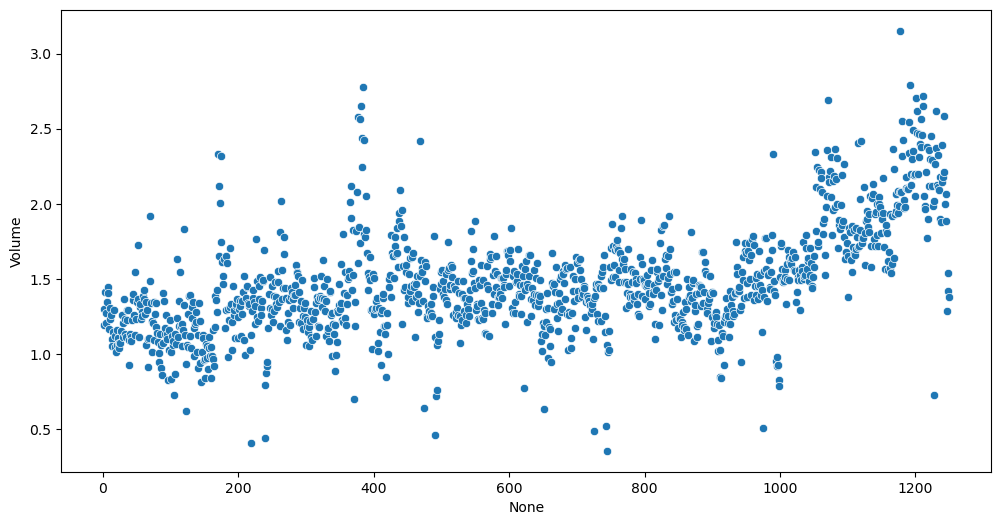

In [11]:
# volumn scatter plot
plt.figure(figsize = (12,6))
sns.scatterplot(x=data.index, y=data['Volume'])

## 4.6.2 Logistic Regression

In [18]:
#store a copy of the original data, as we are going to make some changes in the data
data_orig = data.copy()
data['Direction'] = data['Direction'].map({'Down':0,'Up':1}) # Map up to 1, and down to 0
data.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,1
2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,1
3,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,0
4,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,1
5,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,1


In [19]:
logit = sm.Logit('Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume',data = data)
# The above line was giving error
# sm.Logit() does NOT accept a formula string.

TypeError: BinaryModel.__init__() missing 1 required positional argument: 'exog'

In [24]:
X = data.iloc[:, 1:-2]
X = sm.add_constant(X)   # adds intercept constant column

y = data['Direction']    # must be 0/1 or binary

results = sm.Logit(y, X).fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.691034
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1250
Model:                          Logit   Df Residuals:                     1243
Method:                           MLE   Df Model:                            6
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                0.002074
Time:                        11:26:46   Log-Likelihood:                -863.79
converged:                       True   LL-Null:                       -865.59
Covariance Type:            nonrobust   LLR p-value:                    0.7319
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1260      0.241     -0.523      0.601      -0.598       0.346
Lag1          -0.0731      0.

In [26]:
# probablitie that the given oberstaion will result in 'UP'
prob = results.predict(X)[:10]
print(list(prob))

predicted_classes = np.where(prob <=0.5,'Down','Up') # If the predicted value > 0.5 then up, otherwise down
pd.DataFrame({'Probabilities':prob,'Classes':predicted_classes})

[0.5070841334630002, 0.48146787817516973, 0.4811388348131379, 0.5152223557927659, 0.5107811625911515, 0.5069564604552573, 0.49265087386752915, 0.5092291581449722, 0.5176135261687921, 0.4888377794207711]


,Probabilities,Classes
1,0.507084,Up
2,0.481468,Down
3,0.481139,Down
4,0.515222,Up
5,0.510781,Up
6,0.506956,Up
7,0.492651,Down
8,0.509229,Up
9,0.517614,Up
10,0.488838,Down


In [27]:
# confusion matrix and accuracy
# Using sklearn
lr = LogisticRegression()
lr.fit(X,y)
lr.coef_
# we can see that sklearn and statsmodel, don't have the exact same coefficients

array([[-0.05909243, -0.07291454, -0.04230471,  0.01099881,  0.00927633,
         0.0102685 ,  0.13115439]])

In [29]:
cm = confusion_matrix(y,lr.predict(X))
accuracy = accuracy_score(y,lr.predict(X)) # correct predictions / total predictions

print('Accuracy is ',accuracy)
print('confusion_matrix - ')
print(cm)

Accuracy is  0.5208
confusion_matrix - 
[[144 458]
 [141 507]]


NOTE - Confusion matrix drawn in some of the textbooks have actual values as columns, and predicted values as rows.
       While in Sklearn, actual values are as rows, and predicted values are as columns.

In [31]:
#using statsmodel
table = results.pred_table(threshold=0.5)
table # Use the propability threadshold to generate confusion matrix

array([[145., 457.],
       [141., 507.]])

#### Computing train and test accuracy

In [33]:
train = data[data['Year']<2005]
test = data[data['Year'] == 2005]
print('Shape of train is',train.shape)
print('Shape of test is ',test.shape)

Shape of train is (998, 9)
Shape of test is  (252, 9)


In [34]:
X_train = train.iloc[:,1:-2]
X_train = sm.add_constant(X_train)
y_train = train['Direction']

X_test = test.iloc[:,1:-2]
X_test = sm.add_constant(X_test)
y_test = test['Direction']

In [35]:
results = sm.Logit(y_train,X_train).fit()
pred_test = results.predict(X_test)

Optimization terminated successfully.
         Current function value: 0.691936
         Iterations 4


In [36]:
pred_classes = np.where(pred_test > 0.5,1,0)
cm = confusion_matrix(y_test,pred_classes)
cm

array([[77, 34],
       [97, 44]], dtype=int64)

In [37]:
accuracy = accuracy_score(y_test,pred_classes)
print('Accuracy is ',accuracy)

Accuracy is  0.4801587301587302


In [ ]:
# The accuracy is just 48%, even random guessing will do a better job.

In [38]:
# Using only Lag1 and lag 2
predictors = ['Lag1','Lag2']
X_train = train[predictors]
X_train = sm.add_constant(X_train)

X_test = test[predictors]
X_test = sm.add_constant(X_test)
# y_train and y_test remains the same

In [39]:
results = sm.Logit(y_train,X_train).fit()
pred_test = results.predict(X_test)

Optimization terminated successfully.
         Current function value: 0.692085
         Iterations 3


In [40]:
pred_classes = np.where(pred_test > 0.5,1,0)
cm = confusion_matrix(y_test,pred_classes)
cm

array([[ 35,  76],
       [ 35, 106]], dtype=int64)

In [41]:
accuracy = accuracy_score(y_test,pred_classes)
print('Accuracy is ',accuracy)

Accuracy is  0.5595238095238095


In [ ]:
# the accuracy is better that before

In [42]:
X_test

,const,Lag1,Lag2
999,1.0,-0.134,0.008
1000,1.0,-0.812,-0.134
1001,1.0,-1.167,-0.812
1002,1.0,-0.363,-1.167
1003,1.0,0.351,-0.363
...,...,...,...
1246,1.0,0.422,0.252
1247,1.0,0.043,0.422
1248,1.0,-0.955,0.043
1249,1.0,0.130,-0.955


In [ ]:
# prediction
results.predict([[1,1.2,1.1],
                 [1,1.5,-0.8]])

array([0.47914624, 0.49609387])

## 4.6.5 K-Nearest Neighbors

In [43]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [44]:
pred = knn.predict(X_test)

In [45]:
print('Accuracy using KNN for 1 nieghbor is ',accuracy_score(y_test,pred))

Accuracy using KNN for 1 nieghbor is  0.5


In [46]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
pred = knn.predict(X_test)
print('Accuracy using KNN for 3 nieghbor is ',accuracy_score(y_test,pred))

Accuracy using KNN for 3 nieghbor is  0.5317460317460317


In [ ]:
# Even if we increase n to 3, accuracy is 53.17

## 4.6.6 An Application to Caravan Insurance Data


In [53]:
data = pd.read_csv(r'D:\UG Files\Year 4\S3\STATS 302\Codes\STATS-302-Intro-to-ML\Regression\Week_2_Data\Caravan-1.csv',index_col=0)
# data = data.drop(data.columns[0], axis=1)
print(data.shape)
data.tail()

(5822, 86)


,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
5818,36,1,1,2,8,0,6,1,2,1,...,0,0,0,1,0,0,0,0,0,No
5819,35,1,4,4,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
5820,33,1,3,4,8,0,6,0,3,5,...,0,0,0,1,0,0,0,0,0,Yes
5821,34,1,3,2,8,0,7,0,2,7,...,0,0,0,0,0,0,0,0,0,No
5822,33,1,3,3,8,0,6,1,2,7,...,0,0,0,0,0,0,0,0,0,No


In [50]:
data['Purchase'].value_counts() / len(data)
# Only around 6% of the people purchased the insurance.

Purchase
No     0.940227
Yes    0.059773
Name: count, dtype: float64

In [52]:
# From a sample of means if the observations it can be seen that the variables falls in different ranges
# We want all the variables to have a same range.
data.iloc[:, :5].mean()

MOSTYPE     24.253349
MAANTHUI     1.110615
MGEMOMV      2.678805
MGEMLEEF     2.991240
MOSHOOFD     5.773617
dtype: float64

In [ ]:
# we will apply standard scaler which will transform the data such that it has 0  mean, and std deviation of 1
# but before that lets split the data into test and train data

In [54]:
test = data.iloc[:1000,:]
train = data.iloc[1000:,:]

X_train = train.drop('Purchase',axis = 1) # axis=0 rows, axis=1 columns
y_train = train['Purchase']
X_test = test.drop('Purchase',axis = 1)
y_test = test['Purchase']

In [55]:
# Applying the standard Scaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) # Fit first to find the mean and variance and then transform
X_test = scaler.transform(X_test) # Use the same normalization for training data to transform test data

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [56]:
# changing labels from string to binary
y_train = np.where(y_train == 'Yes',1,0)
y_test = np.where(y_test == 'Yes',1,0)

In [57]:
# KNN with n_neighbors = 1
knn_1 = KNeighborsClassifier(n_neighbors=1)

knn_1.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [58]:
pred = knn_1.predict(X_test)
cm = confusion_matrix(y_test,pred)
print('The accuracy for k = 1 is ',accuracy_score(y_test,pred))
print('Confusion Matrix')
pd.DataFrame(cm,columns = ['No','Yes'],index = ['No','Yes'])

The accuracy for k = 1 is  0.883
Confusion Matrix


,No,Yes
No,874,67
Yes,50,9


In [ ]:
# Out of 76 predicted values, 9 are in True in real.
# accuracy = 11%

In [59]:
# KNN with n_neighbors = 3
knn_3 = KNeighborsClassifier(n_neighbors=3)

knn_3.fit(X_train,y_train)

pred = knn_3.predict(X_test)
cm = confusion_matrix(y_test,pred)
print('The accuracy for k = 3 is ',accuracy_score(y_test,pred))
print('Confusion Matrix')
pd.DataFrame(cm,columns = ['No','Yes'],index = ['No','Yes'])

The accuracy for k = 3 is  0.926
Confusion Matrix


,No,Yes
No,920,21
Yes,53,6


In [ ]:
# for 27 total predicted values, 6 are Yes in real
# Accuracy is 22%

In [60]:
# KNN with n_neighbors = 5
knn_5 = KNeighborsClassifier(n_neighbors=5)

knn_5.fit(X_train,y_train)

pred = knn_5.predict(X_test)
cm = confusion_matrix(y_test,pred)
print('The accuracy for k = 5 is ',accuracy_score(y_test,pred))
print('Confusion Matrix')
pd.DataFrame(cm,columns = ['No','Yes'],index = ['No','Yes'])

The accuracy for k = 5 is  0.934
Confusion Matrix


,No,Yes
No,931,10
Yes,56,3


In [ ]:
# for k = 5, accuracy is 23%

## Additional  - Finding the optimal value of k

In [61]:
def run_knn(n_neighbors):
    accuracy_list = []
    for n in n_neighbors:
        knn = KNeighborsClassifier(n_neighbors=n)

        knn.fit(X_train,y_train)

        pred = knn.predict(X_test)
        accuracy_list.append(accuracy_score(y_test,pred))
    return accuracy_list

Text(0, 0.5, 'Test Accuracy')

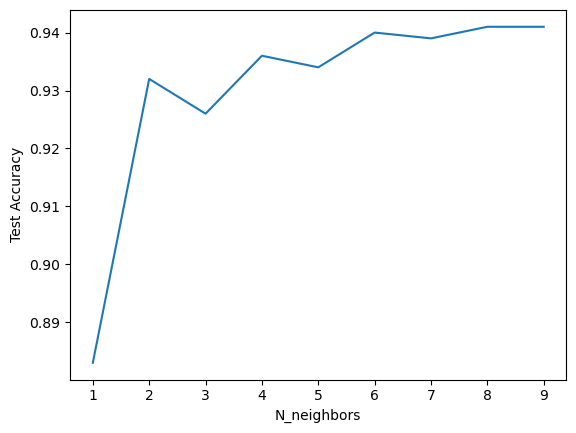

In [62]:
neighbors = [i for i in range(1,10)]
accuracy_list = run_knn(neighbors)
plt.plot(neighbors,accuracy_list)
plt.xlabel('N_neighbors')
plt.ylabel('Test Accuracy')